#  NLP Assignment 3

## ID: i232607


In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import os
%cd "/content/drive/MyDrive/i232607-NLP-Assignment3"


/content/drive/MyDrive/i232607-NLP-Assignment3


In [34]:
import os
import re
import json
import random
from collections import Counter

import numpy as np
import torch
from sklearn.model_selection import train_test_split

In [35]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
DATA_DIR = "dataset"
MODELS_DIR = "models"
RESULTS_DIR = "results"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Folders ready:", MODELS_DIR, RESULTS_DIR)

Folders ready: models results


In [36]:
# Config for dataset and preprocessing
CATEGORY_FILES = {
    "beauty": "Beauty_5.json",
    "cellphones": "Cell_Phones_and_Accessories_5.json",
    "sports": "Sports_and_Outdoors_5.json",
}

SAMPLES_PER_CATEGORY = 10000   # change to 12000 or 15000 if needed
MAX_LEN = 120                  # fixed sequence length
MIN_FREQ = 2                   # min token frequency for vocab

print("Using", SAMPLES_PER_CATEGORY, "reviews per category")

Using 10000 reviews per category


In [37]:
def read_reviews(path, category_name, limit):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                obj = json.loads(line)
            except Exception:
                continue

            text = obj.get("reviewText", "")
            rating = obj.get("overall", None)

            if text is None:
                text = ""
            text = str(text).strip()

            if rating is None:
                continue
            try:
                rating = int(round(float(rating)))
            except Exception:
                continue

            if rating < 1 or rating > 5:
                continue
            if len(text) == 0:
                continue

            rows.append({
                "text": text,
                "rating": rating,
                "category": category_name
            })

    if len(rows) < limit:
        print(f"Warning: {category_name} has only {len(rows)} usable reviews")
        return rows

    random.shuffle(rows)
    return rows[:limit]


def rating_to_sentiment(r):
    if r <= 2:
        return 0  # negative
    if r == 3:
        return 1  # neutral
    return 2      # positive


all_rows = []
for cat, file_name in CATEGORY_FILES.items():
    full_path = os.path.join(DATA_DIR, file_name)
    part = read_reviews(full_path, cat, SAMPLES_PER_CATEGORY)
    all_rows.extend(part)
    print(cat, "->", len(part))

print("Total rows:", len(all_rows))

beauty -> 10000
cellphones -> 10000
sports -> 10000
Total rows: 30000


In [38]:
# Train/val/test split: 70/15/15
train_rows, temp_rows = train_test_split(all_rows, test_size=0.30, random_state=SEED, shuffle=True)
val_rows, test_rows = train_test_split(temp_rows, test_size=0.50, random_state=SEED, shuffle=True)

print("Train:", len(train_rows))
print("Val:  ", len(val_rows))
print("Test: ", len(test_rows))


def show_label_stats(rows, name):
    sent_counts = Counter()
    cat_counts = Counter()
    for x in rows:
        sent_counts[rating_to_sentiment(x["rating"])] += 1
        cat_counts[x["category"]] += 1

    print(f"\n{name} sentiment counts (0=neg,1=neu,2=pos):", dict(sent_counts))
    print(f"{name} category counts:", dict(cat_counts))


show_label_stats(train_rows, "Train")
show_label_stats(val_rows, "Val")
show_label_stats(test_rows, "Test")

Train: 21000
Val:   4500
Test:  4500

Train sentiment counts (0=neg,1=neu,2=pos): {2: 16730, 1: 2118, 0: 2152}
Train category counts: {'sports': 7006, 'cellphones': 7002, 'beauty': 6992}

Val sentiment counts (0=neg,1=neu,2=pos): {2: 3547, 1: 473, 0: 480}
Val category counts: {'beauty': 1469, 'sports': 1498, 'cellphones': 1533}

Test sentiment counts (0=neg,1=neu,2=pos): {2: 3634, 0: 425, 1: 441}
Test category counts: {'sports': 1496, 'beauty': 1539, 'cellphones': 1465}


In [39]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s\.,!?;:'\"()\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text):
    # Split words and punctuation separately
    tokens = re.findall(r"[a-z0-9]+|[^\w\s]", text)
    return tokens


def build_vocab(rows, min_freq=2):
    counter = Counter()
    for row in rows:
        txt = clean_text(row["text"])
        tokens = tokenize(txt)
        for t in tokens:
            counter[t] += 1

    vocab = {
        "<PAD>": 0,
        "<UNK>": 1
    }

    for token, freq in counter.items():
        if freq >= min_freq:
            vocab[token] = len(vocab)

    return vocab


def encode_tokens(tokens, vocab):
    ids = []
    unk = vocab["<UNK>"]
    for t in tokens:
        ids.append(vocab.get(t, unk))
    return ids


def pad_or_truncate(ids, max_len, pad_id=0):
    if len(ids) > max_len:
        return ids[:max_len]
    if len(ids) < max_len:
        ids = ids + [pad_id] * (max_len - len(ids))
    return ids

In [40]:
# Build labels for second task (category prediction)
category_to_id = {
    "beauty": 0,
    "cellphones": 1,
    "sports": 2,
}
id_to_category = {v: k for k, v in category_to_id.items()}

# Build vocabulary from training data only
vocab = build_vocab(train_rows, min_freq=MIN_FREQ)
print("Vocab size:", len(vocab))


def process_rows(rows, vocab, max_len):
    x_data = []
    y_sent = []
    y_cat = []

    for row in rows:
        text = clean_text(row["text"])
        tokens = tokenize(text)
        ids = encode_tokens(tokens, vocab)
        ids = pad_or_truncate(ids, max_len=max_len, pad_id=vocab["<PAD>"])

        x_data.append(ids)
        y_sent.append(rating_to_sentiment(row["rating"]))
        y_cat.append(category_to_id[row["category"]])

    x_data = torch.tensor(x_data, dtype=torch.long)
    y_sent = torch.tensor(y_sent, dtype=torch.long)
    y_cat = torch.tensor(y_cat, dtype=torch.long)

    return x_data, y_sent, y_cat


X_train, y_train_sent, y_train_cat = process_rows(train_rows, vocab, MAX_LEN)
X_val, y_val_sent, y_val_cat = process_rows(val_rows, vocab, MAX_LEN)
X_test, y_test_sent, y_test_cat = process_rows(test_rows, vocab, MAX_LEN)

print("X_train shape:", tuple(X_train.shape))
print("X_val shape:  ", tuple(X_val.shape))
print("X_test shape: ", tuple(X_test.shape))

Vocab size: 18407
X_train shape: (21000, 120)
X_val shape:   (4500, 120)
X_test shape:  (4500, 120)


In [41]:
# Save processed data for next sections
prep_data = {
    "X_train": X_train,
    "X_val": X_val,
    "X_test": X_test,
    "y_train_sent": y_train_sent,
    "y_val_sent": y_val_sent,
    "y_test_sent": y_test_sent,
    "y_train_cat": y_train_cat,
    "y_val_cat": y_val_cat,
    "y_test_cat": y_test_cat,
    "vocab": vocab,
    "category_to_id": category_to_id,
    "id_to_category": id_to_category,
    "max_len": MAX_LEN,
}

torch.save(prep_data, os.path.join(RESULTS_DIR, "prep_data.pt"))
print("Saved:", os.path.join(RESULTS_DIR, "prep_data.pt"))

# Quick sanity check
print("Example token ids (first 20):", X_train[0][:20].tolist())
print("Example labels (sentiment, category):", y_train_sent[0].item(), y_train_cat[0].item())

Saved: results/prep_data.pt
Example token ids (first 20): [2, 3, 4, 5, 6, 7, 2, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Example labels (sentiment, category): 2 2


## Section 2 - Part A: Encoder-only Transformer (Multi-task)

This section trains an encoder-only Transformer for:
1. Sentiment classification (negative/neutral/positive)
2. Category classification (beauty/cellphones/sports)

It also saves:
- trained encoder model weights in `models/`
- review embeddings in `results/` for retrieval in Part B

In [42]:
import math
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score

In [43]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

BATCH_SIZE = 64
EPOCHS = 6
LR = 1e-3
EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.1

Device: cuda


In [44]:
train_ds = TensorDataset(X_train, y_train_sent, y_train_cat)
val_ds = TensorDataset(X_val, y_val_sent, y_val_cat)
test_ds = TensorDataset(X_test, y_test_sent, y_test_cat)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 329
Val batches: 71
Test batches: 71


In [45]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, attn_mask=None):
        bsz, seq_len, _ = x.size()

        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        q = q.view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask == 0, -1e9)

        weights = torch.softmax(scores, dim=-1)
        weights = self.drop(weights)

        ctx = torch.matmul(weights, v)
        ctx = ctx.transpose(1, 2).contiguous().view(bsz, seq_len, self.d_model)

        out = self.out(ctx)
        return out

In [46]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )

        self.drop = nn.Dropout(dropout)

    def forward(self, x, attn_mask=None):
        a = self.attn(x, attn_mask)
        x = self.norm1(x + self.drop(a))

        f = self.ff(x)
        x = self.norm2(x + self.drop(f))
        return x

In [47]:
class EncoderClassifier(nn.Module):
    def __init__(self, vocab_size, max_len, d_model, num_heads, ff_dim, num_layers, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)
        ])

        self.sent_head = nn.Linear(d_model, 3)
        self.cat_head = nn.Linear(d_model, 3)

    def forward(self, x):
        bsz, seq_len = x.size()
        pos = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(bsz, seq_len)

        out = self.token_emb(x) + self.pos_emb(pos)
        out = self.drop(out)

        pad_mask = (x != 0).unsqueeze(1).unsqueeze(2)

        for layer in self.layers:
            out = layer(out, pad_mask)

        # Mean pool over non-pad tokens only
        mask = (x != 0).unsqueeze(-1).float()
        summed = (out * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-6)
        review_vec = summed / counts

        sent_logits = self.sent_head(review_vec)
        cat_logits = self.cat_head(review_vec)

        return sent_logits, cat_logits, review_vec

In [48]:
model = EncoderClassifier(
    vocab_size=len(vocab),
    max_len=MAX_LEN,
    d_model=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

criterion_sent = nn.CrossEntropyLoss()
criterion_cat = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model.__class__.__name__)

EncoderClassifier


In [49]:
def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_sent_true = []
    all_sent_pred = []
    all_cat_true = []
    all_cat_pred = []

    for x, y_sent, y_cat in loader:
        x = x.to(DEVICE)
        y_sent = y_sent.to(DEVICE)
        y_cat = y_cat.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            out_sent, out_cat, _ = model(x)
            loss_sent = criterion_sent(out_sent, y_sent)
            loss_cat = criterion_cat(out_cat, y_cat)
            loss = loss_sent + loss_cat

            if train_mode:
                loss.backward()
                optimizer.step()

        total_loss += loss.item()

        pred_sent = torch.argmax(out_sent, dim=1)
        pred_cat = torch.argmax(out_cat, dim=1)

        all_sent_true.extend(y_sent.cpu().numpy().tolist())
        all_sent_pred.extend(pred_sent.cpu().numpy().tolist())
        all_cat_true.extend(y_cat.cpu().numpy().tolist())
        all_cat_pred.extend(pred_cat.cpu().numpy().tolist())

    avg_loss = total_loss / len(loader)
    sent_acc = accuracy_score(all_sent_true, all_sent_pred)
    cat_acc = accuracy_score(all_cat_true, all_cat_pred)
    sent_f1 = f1_score(all_sent_true, all_sent_pred, average="macro")
    cat_f1 = f1_score(all_cat_true, all_cat_pred, average="macro")

    return {
        "loss": avg_loss,
        "sent_acc": sent_acc,
        "cat_acc": cat_acc,
        "sent_f1": sent_f1,
        "cat_f1": cat_f1,
    }

In [50]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_sent_acc": [],
    "val_sent_acc": [],
    "train_cat_acc": [],
    "val_cat_acc": [],
}

best_val = 1e9
best_model_path = os.path.join(MODELS_DIR, "part_a_encoder.pt")

for epoch in range(1, EPOCHS + 1):
    train_stats = run_epoch(model, train_loader, optimizer=optimizer)
    val_stats = run_epoch(model, val_loader, optimizer=None)

    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["train_sent_acc"].append(train_stats["sent_acc"])
    history["val_sent_acc"].append(val_stats["sent_acc"])
    history["train_cat_acc"].append(train_stats["cat_acc"])
    history["val_cat_acc"].append(val_stats["cat_acc"])

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_stats['loss']:.4f} | Val Loss: {val_stats['loss']:.4f} | "
        f"Train Sent Acc: {train_stats['sent_acc']:.4f} | Val Sent Acc: {val_stats['sent_acc']:.4f} | "
        f"Train Cat Acc: {train_stats['cat_acc']:.4f} | Val Cat Acc: {val_stats['cat_acc']:.4f}"
    )

    if val_stats["loss"] < best_val:
        best_val = val_stats["loss"]
        torch.save(model.state_dict(), best_model_path)

print("Best model saved at:", best_model_path)

Epoch 1/6 | Train Loss: 1.2240 | Val Loss: 0.9761 | Train Sent Acc: 0.7965 | Val Sent Acc: 0.7902 | Train Cat Acc: 0.7385 | Val Cat Acc: 0.8556
Epoch 2/6 | Train Loss: 0.8960 | Val Loss: 0.8533 | Train Sent Acc: 0.8011 | Val Sent Acc: 0.7964 | Train Cat Acc: 0.8693 | Val Cat Acc: 0.8876
Epoch 3/6 | Train Loss: 0.7681 | Val Loss: 0.8125 | Train Sent Acc: 0.8102 | Val Sent Acc: 0.7993 | Train Cat Acc: 0.9095 | Val Cat Acc: 0.9064
Epoch 4/6 | Train Loss: 0.6856 | Val Loss: 0.7791 | Train Sent Acc: 0.8196 | Val Sent Acc: 0.8058 | Train Cat Acc: 0.9264 | Val Cat Acc: 0.9082
Epoch 5/6 | Train Loss: 0.6205 | Val Loss: 0.7974 | Train Sent Acc: 0.8309 | Val Sent Acc: 0.7904 | Train Cat Acc: 0.9378 | Val Cat Acc: 0.9149
Epoch 6/6 | Train Loss: 0.5571 | Val Loss: 0.7890 | Train Sent Acc: 0.8410 | Val Sent Acc: 0.7987 | Train Cat Acc: 0.9503 | Val Cat Acc: 0.9178
Best model saved at: models/part_a_encoder.pt


In [51]:
# Load best model and evaluate on test
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

test_stats = run_epoch(model, test_loader, optimizer=None)
print("\nTest Metrics")
print("Loss:", round(test_stats["loss"], 4))
print("Sentiment Accuracy:", round(test_stats["sent_acc"], 4))
print("Sentiment Macro F1:", round(test_stats["sent_f1"], 4))
print("Category Accuracy:", round(test_stats["cat_acc"], 4))
print("Category Macro F1:", round(test_stats["cat_f1"], 4))


Test Metrics
Loss: 0.7609
Sentiment Accuracy: 0.8258
Sentiment Macro F1: 0.46
Category Accuracy: 0.8958
Category Macro F1: 0.8953


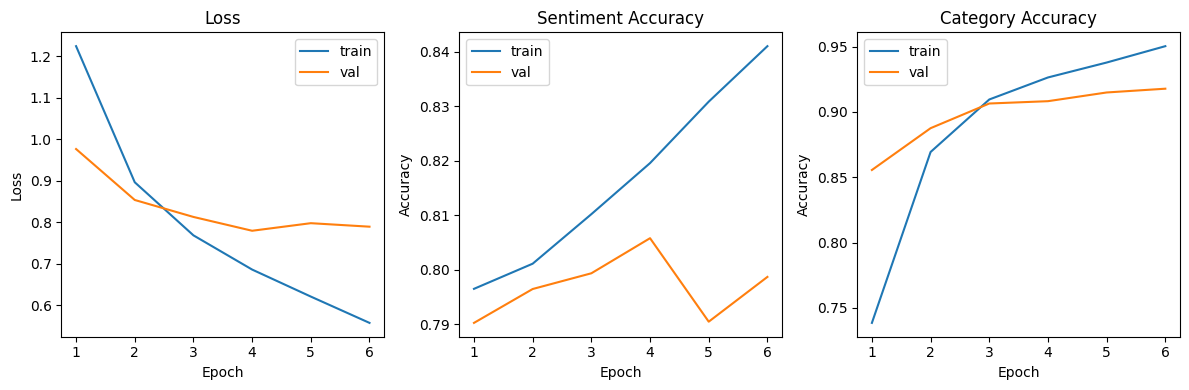

In [52]:
# Learning curves
epochs_axis = list(range(1, EPOCHS + 1))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs_axis, history["train_loss"], label="train")
plt.plot(epochs_axis, history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_axis, history["train_sent_acc"], label="train")
plt.plot(epochs_axis, history["val_sent_acc"], label="val")
plt.title("Sentiment Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_axis, history["train_cat_acc"], label="train")
plt.plot(epochs_axis, history["val_cat_acc"], label="val")
plt.title("Category Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [53]:
def get_embeddings(model, x_tensor, batch_size=256):
    model.eval()
    all_vecs = []
    all_sent_pred = []
    all_cat_pred = []

    with torch.no_grad():
        for i in range(0, len(x_tensor), batch_size):
            xb = x_tensor[i:i + batch_size].to(DEVICE)
            out_sent, out_cat, vec = model(xb)

            all_vecs.append(vec.cpu())
            all_sent_pred.append(torch.argmax(out_sent, dim=1).cpu())
            all_cat_pred.append(torch.argmax(out_cat, dim=1).cpu())

    all_vecs = torch.cat(all_vecs, dim=0)
    all_sent_pred = torch.cat(all_sent_pred, dim=0)
    all_cat_pred = torch.cat(all_cat_pred, dim=0)

    return all_vecs, all_sent_pred, all_cat_pred


train_embeddings, train_sent_pred, train_cat_pred = get_embeddings(model, X_train)
val_embeddings, val_sent_pred, val_cat_pred = get_embeddings(model, X_val)
test_embeddings, test_sent_pred, test_cat_pred = get_embeddings(model, X_test)

print("Train embeddings:", tuple(train_embeddings.shape))
print("Val embeddings:", tuple(val_embeddings.shape))
print("Test embeddings:", tuple(test_embeddings.shape))

Train embeddings: (21000, 128)
Val embeddings: (4500, 128)
Test embeddings: (4500, 128)


In [54]:
# Save outputs needed for Part B
emb_path = os.path.join(RESULTS_DIR, "part_a_embeddings.pt")

torch.save({
    "train_embeddings": train_embeddings,
    "val_embeddings": val_embeddings,
    "test_embeddings": test_embeddings,
    "train_sent_pred": train_sent_pred,
    "val_sent_pred": val_sent_pred,
    "test_sent_pred": test_sent_pred,
    "train_cat_pred": train_cat_pred,
    "val_cat_pred": val_cat_pred,
    "test_cat_pred": test_cat_pred,
    "train_rows": train_rows,
    "val_rows": val_rows,
    "test_rows": test_rows,
}, emb_path)

print("Saved embeddings file:", emb_path)
print("Saved model file:", best_model_path)

Saved embeddings file: results/part_a_embeddings.pt
Saved model file: models/part_a_encoder.pt


## Section 3 - Part B: Retrieval Module

This section uses Part A review vectors to retrieve top-k most similar training reviews
using cosine similarity. Retrieved context is saved for Part C.

In [55]:
# Load saved vectors from Part A
part_a_data = torch.load(os.path.join(RESULTS_DIR, "part_a_embeddings.pt"), map_location="cpu")

train_embeddings = part_a_data["train_embeddings"].float()
val_embeddings = part_a_data["val_embeddings"].float()
test_embeddings = part_a_data["test_embeddings"].float()

train_rows = part_a_data["train_rows"]
val_rows = part_a_data["val_rows"]
test_rows = part_a_data["test_rows"]

print("Loaded embeddings")
print("Train:", tuple(train_embeddings.shape))
print("Val:  ", tuple(val_embeddings.shape))
print("Test: ", tuple(test_embeddings.shape))

Loaded embeddings
Train: (21000, 128)
Val:   (4500, 128)
Test:  (4500, 128)


In [56]:
TOP_K = 3  # easy to change


def l2_normalize(x, eps=1e-8):
    norm = torch.norm(x, p=2, dim=1, keepdim=True)
    return x / (norm + eps)


# Pre-normalize for cosine similarity
train_emb_norm = l2_normalize(train_embeddings)
val_emb_norm = l2_normalize(val_embeddings)
test_emb_norm = l2_normalize(test_embeddings)

print("TOP_K =", TOP_K)

TOP_K = 3


In [57]:
def retrieve_top_k(query_vec, db_vectors_norm, k=3):
    # query_vec shape: (d,)
    q = query_vec.unsqueeze(0)
    q = l2_normalize(q)

    sims = torch.matmul(db_vectors_norm, q.t()).squeeze(1)
    top_vals, top_idx = torch.topk(sims, k=k)

    return top_idx.tolist(), top_vals.tolist()


def retrieve_for_split(query_vectors_norm, db_vectors_norm, db_rows, k=3):
    all_idx = []
    all_scores = []

    for i in range(query_vectors_norm.size(0)):
        idx, scores = retrieve_top_k(query_vectors_norm[i], db_vectors_norm, k=k)
        all_idx.append(idx)
        all_scores.append(scores)

    retrieved_rows = []
    for one_idx_list in all_idx:
        temp = []
        for j in one_idx_list:
            temp.append(db_rows[j])
        retrieved_rows.append(temp)

    return all_idx, all_scores, retrieved_rows

In [58]:
# Retrieve for validation and test queries against train database
val_ret_idx, val_ret_scores, val_ret_rows = retrieve_for_split(
    val_emb_norm, train_emb_norm, train_rows, k=TOP_K
)

test_ret_idx, test_ret_scores, test_ret_rows = retrieve_for_split(
    test_emb_norm, train_emb_norm, train_rows, k=TOP_K
)

print("Validation retrieval done:", len(val_ret_idx))
print("Test retrieval done:", len(test_ret_idx))
print("Each query retrieves:", TOP_K, "reviews")

Validation retrieval done: 4500
Test retrieval done: 4500
Each query retrieves: 3 reviews


In [59]:
def short_text(s, n=220):
    s = s.replace("\n", " ").strip()
    if len(s) <= n:
        return s
    return s[:n] + "..."


def print_retrieval_examples(query_rows, ret_rows, ret_scores, n_examples=5):
    pick = min(n_examples, len(query_rows))
    step = max(1, len(query_rows) // pick)

    shown = 0
    i = 0
    while shown < pick and i < len(query_rows):
        q = query_rows[i]
        print("=" * 90)
        print("Query", shown + 1)
        print("Query category:", q["category"], "| Query rating:", q["rating"])
        print("Query text:", short_text(q["text"]))
        print("-" * 90)

        for r in range(len(ret_rows[i])):
            item = ret_rows[i][r]
            score = ret_scores[i][r]
            print(f"Top-{r+1} | score={score:.4f} | cat={item['category']} | rating={item['rating']}")
            print(short_text(item["text"]))
            print()

        shown += 1
        i += step


print_retrieval_examples(test_rows, test_ret_rows, test_ret_scores, n_examples=5)

Query 1
Query category: sports | Query rating: 5
Query text: Pros1) Reduces friction of bearing - bearing, axle nut - bearing friction2) Useful for bicycle break down - clean - reassemble on axle, bottom bracket and, fork.ConsNo problems to date.
------------------------------------------------------------------------------------------
Top-1 | score=0.9768 | cat=sports | rating=5
I watched a video on Youtube and matched how they attached it to a mossberg 500. Every thing fits very nice and snug. For the screw that attaches the saddle to the breach I used some locktite as it will come loose. The n...

Top-2 | score=0.9751 | cat=sports | rating=5
Works well, basically a neccesity when your after an accrurate and even pull to set crossbow. Shot placement inheirently improved and helps your arms not fatigue as quickly when shooting with friends. After 20 pulls by h...

Top-3 | score=0.9739 | cat=sports | rating=5
Well worth the money. It makes it much easier to drop the mag and insert a ne

In [60]:
def retrieval_match_rate(query_rows, ret_rows):
    same_cat = 0
    same_sent = 0
    total = len(query_rows)

    for i in range(total):
        q_cat = query_rows[i]["category"]
        q_sent = rating_to_sentiment(query_rows[i]["rating"])

        hit_cat = 0
        hit_sent = 0
        for item in ret_rows[i]:
            if item["category"] == q_cat:
                hit_cat += 1
            if rating_to_sentiment(item["rating"]) == q_sent:
                hit_sent += 1

        if hit_cat > 0:
            same_cat += 1
        if hit_sent > 0:
            same_sent += 1

    return {
        "topk_has_same_category_rate": same_cat / total,
        "topk_has_same_sentiment_rate": same_sent / total,
    }


val_quality = retrieval_match_rate(val_rows, val_ret_rows)
test_quality = retrieval_match_rate(test_rows, test_ret_rows)

print("Validation retrieval quality:")
for k, v in val_quality.items():
    print(k, "=", round(v, 4))

print("\nTest retrieval quality:")
for k, v in test_quality.items():
    print(k, "=", round(v, 4))

Validation retrieval quality:
topk_has_same_category_rate = 0.9471
topk_has_same_sentiment_rate = 0.8731

Test retrieval quality:
topk_has_same_category_rate = 0.9338
topk_has_same_sentiment_rate = 0.8793


In [61]:
# Save retrieval outputs for Part C
retrieval_path = os.path.join(RESULTS_DIR, "part_b_retrieval.pt")

torch.save({
    "top_k": TOP_K,
    "val_ret_idx": val_ret_idx,
    "val_ret_scores": val_ret_scores,
    "val_ret_rows": val_ret_rows,
    "test_ret_idx": test_ret_idx,
    "test_ret_scores": test_ret_scores,
    "test_ret_rows": test_ret_rows,
    "val_quality": val_quality,
    "test_quality": test_quality,
}, retrieval_path)

print("Saved retrieval file:", retrieval_path)

Saved retrieval file: results/part_b_retrieval.pt
